<a href="https://colab.research.google.com/github/MtBalbine/PROJETO-1---ESTATISTICA-E-ANALISE-DE-DADOS/blob/main/VarQuantitativaSus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

Definição de arquivo

In [20]:
arquivo = 'economia_circular.xlsx'
coluna = 'Indice_Sustentabilidade'

Leitura de Planilha


In [21]:
df=pd.read_excel(arquivo)
df

,Porte,Taxa_Circularidade_percent,Indice_Sustentabilidade
0,Pequeno,21.2,27.2
1,Médio,67.5,69.7
2,Médio,37.4,56.4
3,Médio,44.5,52.7
4,Médio,29.5,38.8
...,...,...,...
273,Médio,34.3,48.8
274,Médio,30.5,48.5
275,Pequeno,32.1,46.6
276,Pequeno,47.1,57.4


Extremidades da tabela

In [22]:
valormin=df[coluna].min()
valormax=df[coluna].max()
print (valormin,valormax)

24.3 94.2


Definição de Classes



In [23]:
classes = [20,30,40,50,60,70,80,90,100]
frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))
frequencia.sort_index(ascending=True)

/tmp/ipykernel_1056/316735622.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frequencia = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))


,count
Indice_Sustentabilidade,
"[20, 30)",6
"[30, 40)",34
"[40, 50)",81
"[50, 60)",81
"[60, 70)",44
"[70, 80)",22
"[80, 90)",9
"[90, 100)",1


Frequência Relativa

In [24]:
Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)
Freqpercentual.sort_index(ascending=True)

/tmp/ipykernel_1056/2202019940.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  Freqpercentual = round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)


,proportion
Indice_Sustentabilidade,
"[20, 30)",2.16
"[30, 40)",12.23
"[40, 50)",29.14
"[50, 60)",29.14
"[60, 70)",15.83
"[70, 80)",7.91
"[80, 90)",3.24
"[90, 100)",0.36


Colunas de frequência acumulada e de frequência relativa acumulada


In [25]:
#note que é necessário acumular a coluna da frequência com as classes ordenadas, isto é, usando sort_index
freqacum=np.cumsum(frequencia.sort_index())
freqacum




,count
Indice_Sustentabilidade,
"[20, 30)",6
"[30, 40)",40
"[40, 50)",121
"[50, 60)",202
"[60, 70)",246
"[70, 80)",268
"[80, 90)",277
"[90, 100)",278


In [26]:
freqpercacum=np.cumsum(Freqpercentual.sort_index())
freqpercacum

,proportion
Indice_Sustentabilidade,
"[20, 30)",2.16
"[30, 40)",14.39
"[40, 50)",43.53
"[50, 60)",72.67
"[60, 70)",88.50
"[70, 80)",96.41
"[80, 90)",99.65
"[90, 100)",100.01


 Tabela Geral

In [27]:
dist_freq = pd.DataFrame({'Frequência': frequencia,'Frequência Relativa (%)':Freqpercentual,'Frequência Acumulativa': freqacum,'Frequência Relativa Acumulativa (%)':freqpercacum})
display(dist_freq)
print(f'\n      Variável:{coluna}')
print('     *Limites superiores do intervalo de classes não incluídos')

,Frequência,Frequência Relativa (%),Frequência Acumulativa,Frequência Relativa Acumulativa (%)
Indice_Sustentabilidade,,,,
"[20, 30)",6,2.16,6,2.16
"[30, 40)",34,12.23,40,14.39
"[40, 50)",81,29.14,121,43.53
"[50, 60)",81,29.14,202,72.67
"[60, 70)",44,15.83,246,88.50
"[70, 80)",22,7.91,268,96.41
"[80, 90)",9,3.24,277,99.65
"[90, 100)",1,0.36,278,100.01



      Variável:Indice_Sustentabilidade
     *Limites superiores do intervalo de classes não incluídos


Histograma da Taxa de Circularidade


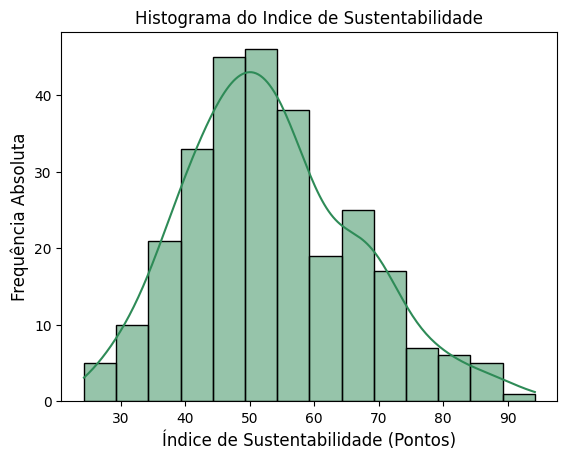

In [28]:
sns.histplot(data=df,x="Indice_Sustentabilidade",kde=True, color="#2E8B57")
plt.ylabel("Frequência Absoluta",size=12)
plt.xlabel("Índice de Sustentabilidade (Pontos)",size=12)
plt.title('Histograma do Indice de Sustentabilidade') # Adiciona o título aqu
plt.show()

In [29]:
valormin=min(df.Indice_Sustentabilidade)
valormax=max(df.Indice_Sustentabilidade)
valormin,valormax


(24.3, 94.2)

Calculo da média, moda e mediana:

In [30]:
#cálculo da Média
df.Indice_Sustentabilidade.mean()

np.float64(53.339928057553955)

In [31]:
# cálculo da moda
df.Indice_Sustentabilidade.mode()

,Indice_Sustentabilidade
0,50.0


In [32]:
#cálculo da mediana
df.Indice_Sustentabilidade.median()

52.0